### Ensemble tech niques is of 2 types :
## 1)Bagging --- Random forest
## 2)Boosting --- Adaboost, X-gboost,Gradient boosting

## 1)Bagging --- Random forest

Here after the Booststrap aggregation all the decision tree outputs majority is taken and decide the output in classification. while incase of regression mean value of the decision trees output taken into consideration.

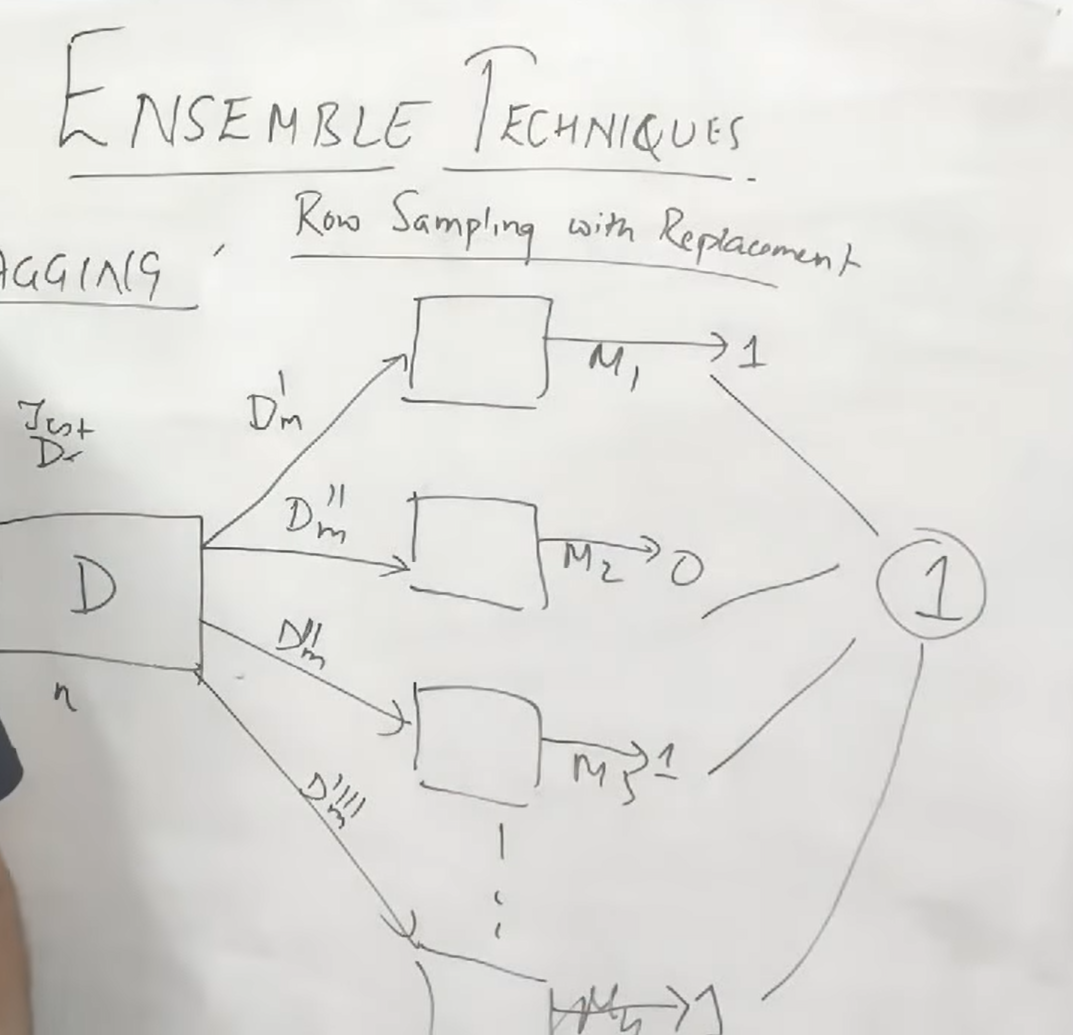

##Datasets and it types :

There are two types of datasets of which one is imbalanced datasets and balanced datasets.

#Balanced datasets :    

In this we dont need to do anything we can directly use it.

#Imbalanced datasets :    

Here the dataset is imbalanced ie:(10000:yes,100:no) so we need to make it as imbalanced datasets inorder to prevent dataleakage.

So we can use undersampling or oversampling. undersampling represents the yes and no should be converted as the least value of yes or no is checked and it converted into the same yes or no ie:(yes:900,no:100 -----> yes:100,no:100)

#### Handling Imbalanced Dataset with Machine Learning

In [ ]:
import pandas as pd
df=pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [ ]:
#### Independent and Dependent Features
X=df.drop("Class",axis=1)
y=df.Class

#### Cross Validation Like KFOLD and Hyperpaqrameter Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import KFold
import numpy as np
from sklearn.model_selection import GridSearchCV

In [ ]:
10.0 **np.arange(-2,3)

array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])

In [ ]:
log_class=LogisticRegression()
grid={'C':10.0 **np.arange(-2,3),'penalty':['l1','l2']}
cv=KFold(n_splits=5,random_state=None,shuffle=False)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7)

In [ ]:
clf=GridSearchCV(log_class,grid,cv=cv,n_jobs=-1,scoring='f1_macro')
clf.fit(X_train,y_train)

c:\users\krish naik\anaconda3\envs\myenv1\lib\site-packages\sklearn\linear_model\_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]),
                         'penalty': ['l1', 'l2']},
             scoring='f1_macro')

In [ ]:
y_pred=clf.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[85251    47]
 [   41   104]]
0.9989700736163291
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85298
           1       0.69      0.72      0.70       145

    accuracy                           1.00     85443
   macro avg       0.84      0.86      0.85     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
347*100

34700

In [ ]:
y_train.value_counts()

0    199017
1       347
Name: Class, dtype: int64

In [ ]:
class_weight=dict({0:1,1:100})

In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(class_weight=class_weight)
classifier.fit(X_train,y_train)

RandomForestClassifier(class_weight={0: 1, 1: 100})

y_pred=classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

In [ ]:
y_pred=classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[85292     6]
 [   30   115]]
0.9995786664794073
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85298
           1       0.95      0.79      0.86       145

    accuracy                           1.00     85443
   macro avg       0.98      0.90      0.93     85443
weighted avg       1.00      1.00      1.00     85443



#### Under Sampling

In [ ]:
from collections import Counter
Counter(y_train)

Counter({0: 199017, 1: 347})

In [ ]:
from collections import Counter
from imblearn.under_sampling import NearMiss
ns=NearMiss(0.8)
X_train_ns,y_train_ns=ns.fit_sample(X_train,y_train)
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_ns)))

c:\users\krish naik\anaconda3\envs\myenv1\lib\site-packages\imblearn\utils\_validation.py:638: FutureWarning: Pass sampling_strategy=0.8 as keyword args. From version 0.9 passing these as positional arguments will result in an error
  FutureWarning)


The number of classes before fit Counter({0: 199017, 1: 347})
The number of classes after fit Counter({0: 433, 1: 347})


In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier()
classifier.fit(X_train_ns,y_train_ns)

RandomForestClassifier()

In [ ]:
y_pred=classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[64448 20850]
 [   10   135]]
0.7558606322343551
              precision    recall  f1-score   support

           0       1.00      0.76      0.86     85298
           1       0.01      0.93      0.01       145

    accuracy                           0.76     85443
   macro avg       0.50      0.84      0.44     85443
weighted avg       1.00      0.76      0.86     85443



##### Over Sampling

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
os=RandomOverSampler(0.75)
X_train_ns,y_train_ns=os.fit_sample(X_train,y_train)
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_ns)))

c:\users\krish naik\anaconda3\envs\myenv1\lib\site-packages\imblearn\utils\_validation.py:638: FutureWarning: Pass sampling_strategy=0.75 as keyword args. From version 0.9 passing these as positional arguments will result in an error
  FutureWarning)


The number of classes before fit Counter({0: 199017, 1: 347})
The number of classes after fit Counter({0: 199017, 1: 149262})


In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier()
classifier.fit(X_train_ns,y_train_ns)

RandomForestClassifier()

In [ ]:
y_pred=classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[85292     6]
 [   27   118]]
0.9996137776061234
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85298
           1       0.95      0.81      0.88       145

    accuracy                           1.00     85443
   macro avg       0.98      0.91      0.94     85443
weighted avg       1.00      1.00      1.00     85443



#### SMOTETomek

In [ ]:
from imblearn.combine import SMOTETomek

In [ ]:
os=SMOTETomek(0.75)
X_train_ns,y_train_ns=os.fit_sample(X_train,y_train)
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_ns)))

c:\users\krish naik\anaconda3\envs\myenv1\lib\site-packages\imblearn\utils\_validation.py:638: FutureWarning: Pass sampling_strategy=0.75 as keyword args. From version 0.9 passing these as positional arguments will result in an error
  FutureWarning)


The number of classes before fit Counter({0: 199017, 1: 347})
The number of classes after fit Counter({0: 198395, 1: 148640})


In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier()
classifier.fit(X_train_ns,y_train_ns)

RandomForestClassifier()

In [ ]:
y_pred=classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[85286    12]
 [   23   122]]
0.9995903701883126
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85298
           1       0.91      0.84      0.87       145

    accuracy                           1.00     85443
   macro avg       0.96      0.92      0.94     85443
weighted avg       1.00      1.00      1.00     85443



#### Ensemble Techniques

In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier

In [ ]:
easy=EasyEnsembleClassifier()
easy.(X_train,y_train)

EasyEnsembleClassifier()

In [ ]:
easy.

In [ ]:
y_pred=easy.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[82382  2916]
 [   14   131]]
0.9657081329073184
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     85298
           1       0.04      0.90      0.08       145

    accuracy                           0.97     85443
   macro avg       0.52      0.93      0.53     85443
weighted avg       1.00      0.97      0.98     85443

